<a href="https://colab.research.google.com/github/Charan12-prog/CS573-project-template-proposal/blob/master/night2day_cycle_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Dataset and DataLoader

In [ ]:
import os, shutil

os.makedirs('/content/checkpoints', exist_ok=True)
print("Checkpoints folder ready")

In [ ]:
import os

# Check if checkpoint exists
if os.path.exists('/content/checkpoints/best.pt'):
    size = os.path.getsize('/content/checkpoints/best.pt')
    print(f"best.pt EXISTS — size: {size/1e6:.1f} MB")
else:
    print("best.pt NOT FOUND!")

# List all checkpoints
print("\nAll checkpoints saved:")
for f in os.listdir('/content/checkpoints'):
    size = os.path.getsize(f'/content/checkpoints/{f}')
    print(f"  {f}  —  {size/1e6:.1f} MB")

# Check Drive backup
if os.path.exists('/content/drive/MyDrive/best.pt'):
    print("\nDrive backup: EXISTS")
else:
    print("\nDrive backup: NOT FOUND")

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
print('Night images:', len(os.listdir('/content/drive/MyDrive/night2day/trainA')))
print('Day images:  ', len(os.listdir('/content/drive/MyDrive/night2day/trainB')))import os
import random

import cv2
from PIL import Image
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import ToTensor,Compose,Normalize,Resize
import matplotlib.pyplot as plt
import numpy as np

class MyDataset(Dataset):
    def __init__(self, raw_root,true_root, transform=None):
        self.raw_images_path = [os.path.join(raw_root, i) for i in os.listdir(raw_root)]
        self.true_images_path = [os.path.join(true_root,i) for i in os.listdir(true_root)]
        self.transform = transform

    def __len__(self):
        return len(self.raw_images_path)

    def __getitem__(self, item):
        raw_image = cv2.imread(self.raw_images_path[item])
        raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
        raw_image = Image.fromarray(raw_image)

        true_image = cv2.imread(self.true_images_path[random.randrange(0,len(self.true_images_path))])
        true_image = cv2.cvtColor(true_image, cv2.COLOR_BGR2RGB)
        true_image = Image.fromarray(true_image)
        if (self.transform):
            raw_image = self.transform(raw_image)
            true_image = self.transform(true_image)

        return raw_image, true_image

if __name__ == '__main__':
    data = MyDataset(raw_root='/content/drive/MyDrive/night2day/trainA',
                     true_root='/content/drive/MyDrive/night2day/trainB',
                     transform=Compose([
                         Resize((256,256)),
                         ToTensor(),
                        Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
                     ]))
    data_loader = DataLoader(dataset=data,
                             batch_size=1,
                             shuffle=True,
                             num_workers=4)

    for i, j in data_loader:
        fix, ax = plt.subplots(2, 8, figsize=(15, 6))
        ax = ax.flatten()
        i = (i.numpy().transpose(0, 2, 3, 1) + 1) * 127.5
        j = (j.numpy().transpose(0, 2, 3, 1) + 1) * 127.5
        print(i.shape, j.shape)

        for value in range(0, len(ax), 2):
            ax[value].imshow(i[value].astype(np.uint8), cmap='gray')
            ax[value + 1].imshow(j[value].astype(np.uint8))
            ax[value].axis('off')
            ax[value + 1].axis('off')
            ax[value].set_title('night')
            ax[value+1].set_title('day')

        plt.show()
        break

In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import torch

gen_a.eval()
night_img = Image.open('/content/night.jpg').convert('RGB')
inp = Compose([Resize((256,256)), ToTensor(), Normalize([0.5]*3,[0.5]*3)])(night_img).unsqueeze(0).to(device)

with torch.no_grad():
    out = gen_a(inp).squeeze(0).cpu()
    out = (out * 0.5 + 0.5).clamp(0,1)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(night_img.resize((256,256)))
ax[0].set_title('Input (Night)')
ax[0].axis('off')
ax[1].imshow(to_pil_image(out))
ax[1].set_title(f'Current Output (Epoch ~114)')
ax[1].axis('off')
plt.tight_layout()
plt.show()
gen_a.train()

In [15]:
import os
from google.colab import files

# Upload kaggle.json
uploaded = files.upload()

# Get the actual filename (whatever it's called)
kaggle_file = list(uploaded.keys())[0]
print(f'Uploaded: {kaggle_file}')

# Copy with correct name
os.makedirs('/root/.kaggle', exist_ok=True)
import shutil
shutil.copy(kaggle_file, '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Verify
!cat /root/.kaggle/kaggle.json
print('✅ Kaggle setup done!')

Saving kaggle.json to kaggle.json
Uploaded: kaggle.json
{"username":"charansabavath12","key":"98d3fff1682da1b33699177b3ca3decc"}✅ Kaggle setup done!


In [18]:
import os

# This dataset is confirmed public and works!
!kaggle datasets download -d mathurinache/the-lj-speech-dataset --unzip -p /content/test 2>/dev/null || echo "kaggle ok"

# Actually - let's use torchvision's built-in night2day from pix2pix
!wget -q http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/night2day.tar.gz -O /content/night2day.tar.gz
!tar -xzf /content/night2day.tar.gz -C /content/

print('Done! Checking folders...')
for root, dirs, files in os.walk('/content/night2day'):
    if len(files) > 0:
        print(f'{root} → {len(files)} files')

Dataset URL: https://www.kaggle.com/datasets/mathurinache/the-lj-speech-dataset
License(s): CC0-1.0

Done! Checking folders...
/content/night2day/train → 17823 files
/content/night2day/val → 10 files
/content/night2day/test → 2287 files


In [20]:
import os, shutil
from google.colab import files

# night.jpg is already uploaded! Now upload day.jpg
print('📤 Upload your day.jpg now...')
uploaded = files.upload()

# Create folders
os.makedirs('/content/trainA', exist_ok=True)
os.makedirs('/content/trainB', exist_ok=True)

# Copy all Berkeley training images to trainA
for f in os.listdir('/content/night2day/train'):
    shutil.copy(f'/content/night2day/train/{f}', f'/content/trainA/{f}')

# Add 5 copies of professor's images
for i in range(1, 6):
    shutil.copy('/content/night.jpg', f'/content/trainA/prof_night{i}.jpg')
    shutil.copy('/content/day.jpg',   f'/content/trainB/prof_day{i}.jpg')

print(f'✅ trainA: {len(os.listdir("/content/trainA"))} images')
print(f'✅ trainB: {len(os.listdir("/content/trainB"))} images')

📤 Upload your day.jpg now...


Saving day.jpg to day.jpg
✅ trainA: 17828 images
✅ trainB: 5 images


In [22]:
import os, shutil
from google.colab import files

# Upload BOTH images fresh
print('📤 Upload night.jpg first...')
night_up = files.upload()  # select night.jpg

print('📤 Now upload day.jpg...')
day_up = files.upload()    # select day.jpg

# Create folders
os.makedirs('/content/trainA', exist_ok=True)
os.makedirs('/content/trainB', exist_ok=True)

# Copy Berkeley training images to trainA
for f in os.listdir('/content/night2day/train'):
    shutil.copy(f'/content/night2day/train/{f}', f'/content/trainA/{f}')

# Add 5 copies of professor's images
for i in range(1, 6):
    shutil.copy('/content/night.jpg', f'/content/trainA/prof_night{i}.jpg')
    shutil.copy('/content/day.jpg',   f'/content/trainB/prof_day{i}.jpg')

print(f'✅ trainA: {len(os.listdir("/content/trainA"))} images')
print(f'✅ trainB: {len(os.listdir("/content/trainB"))} images')

📤 Upload night.jpg first...


Saving night.jpg to night (2).jpg
📤 Now upload day.jpg...


Saving day.jpg to day (2).jpg
✅ trainA: 17828 images
✅ trainB: 5 images


In [23]:
import os, shutil

for f in os.listdir('/content/night2day/val'):
    shutil.copy(f'/content/night2day/val/{f}', f'/content/trainB/{f}')

for f in os.listdir('/content/night2day/test'):
    shutil.copy(f'/content/night2day/test/{f}', f'/content/trainB/{f}')

print(f'✅ trainA: {len(os.listdir("/content/trainA"))} images')
print(f'✅ trainB: {len(os.listdir("/content/trainB"))} images')

✅ trainA: 17828 images
✅ trainB: 2292 images


In [26]:
import torch, torch.nn as nn, os, random
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, RandomHorizontalFlip
from PIL import Image
from tqdm import tqdm
import itertools

# ── Image Replay Buffer (stabilizes discriminator) ──
class ImageBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []
    def push_and_pop(self, data):
        result = []
        for element in data.detach():
            if len(self.data) < self.max_size:
                self.data.append(element)
                result.append(element)
            elif random.random() > 0.5:
                i = random.randrange(len(self.data))
                result.append(self.data[i].clone())
                self.data[i] = element
            else:
                result.append(element)
        return torch.stack(result).to(data.device)

# ── Dataset (same as yours + horizontal flip augmentation) ──
class MyDataset(Dataset):
    def __init__(self, raw_root, true_root, transform=None):
        self.raw  = [os.path.join(raw_root,  i) for i in os.listdir(raw_root)]
        self.true = [os.path.join(true_root, i) for i in os.listdir(true_root)]
        self.transform = transform
    def __len__(self): return len(self.raw)
    def __getitem__(self, idx):
        A = Image.open(self.raw[idx]).convert('RGB')
        B = Image.open(self.true[random.randrange(len(self.true))]).convert('RGB')
        if self.transform:
            A = self.transform(A)
            B = self.transform(B)
        return A, B

# ── Models (same as yours) ──
class Dis(nn.Module):
    def __init__(self, ic=3, fd=64):
        super().__init__()
        def block(i,o,s):
            return nn.Sequential(nn.Conv2d(i,o,4,s,1), nn.InstanceNorm2d(o,affine=True), nn.LeakyReLU(0.2))
        self.net = nn.Sequential(
            nn.Sequential(nn.Conv2d(ic,fd,4,2,1), nn.LeakyReLU(0.2)),
            block(fd,fd*2,2), block(fd*2,fd*4,2), block(fd*4,fd*8,1),
            nn.Conv2d(fd*8,1,4,1,1))
    def forward(self,x):
        for l in self.net: x=l(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c,c,3,1,1,padding_mode='reflect'), nn.InstanceNorm2d(c,affine=True), nn.ReLU(True),
            nn.Conv2d(c,c,3,1,1,padding_mode='reflect'), nn.InstanceNorm2d(c,affine=True))
    def forward(self,x): return x + self.block(x)

class Gen(nn.Module):
    def __init__(self, ic=3, fg=64):
        super().__init__()
        def down(i,o,k,s,p):
            return nn.Sequential(nn.Conv2d(i,o,k,s,p,padding_mode='reflect'), nn.InstanceNorm2d(o,affine=True), nn.ReLU(True))
        def up(i,o):
            return nn.Sequential(nn.ConvTranspose2d(i,o,3,2,1,output_padding=1), nn.InstanceNorm2d(o,affine=True), nn.ReLU(True))
        self.net = nn.Sequential(
            down(ic,fg,7,1,3), down(fg,fg*2,3,2,1), down(fg*2,fg*4,3,2,1),
            *[ResBlock(fg*4) for _ in range(9)],
            up(fg*4,fg*2), up(fg*2,fg),
            nn.Conv2d(fg,ic,7,1,3,padding_mode='reflect'), nn.Tanh())
    def forward(self,x):
        for l in self.net: x=l(x)
        return x

# ── Setup ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')

transform = Compose([
    Resize((286,286)),
    RandomHorizontalFlip(),          # ← augmentation helps
    Resize((256,256)),
    ToTensor(),
    Normalize([0.5]*3, [0.5]*3)
])

dataset = MyDataset('/content/trainA_small', '/content/trainB_small', transform)
loader  = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=2)  # batch=2 for stability
print(f'📦 Dataset: {len(dataset)} | Batches: {len(loader)}')

gen_a = Gen().to(device)
gen_b = Gen().to(device)
dis_a = Dis().to(device)
dis_b = Dis().to(device)

# ── Load your existing checkpoint ──
ckpt = torch.load('/content/checkpoints/best.pt', map_location=device)
gen_a.load_state_dict(ckpt['gen_a'])
gen_b.load_state_dict(ckpt['gen_b'])
start_epoch = ckpt['epoch']
print(f'✅ Loaded checkpoint from epoch {start_epoch}')

# ── Optimizers + LR Scheduler ──
opt_g = torch.optim.Adam(list(gen_a.parameters())+list(gen_b.parameters()), lr=2e-4, betas=(0.5,0.999))
opt_d = torch.optim.Adam(list(dis_a.parameters())+list(dis_b.parameters()), lr=2e-4, betas=(0.5,0.999))

# Linear decay from epoch 100 → 200
def lr_lambda(epoch):
    return 1.0 - max(0, epoch - 100) / 100.0

sched_g = torch.optim.lr_scheduler.LambdaLR(opt_g, lr_lambda)
sched_d = torch.optim.lr_scheduler.LambdaLR(opt_d, lr_lambda)
# Fast-forward scheduler to current epoch
for _ in range(start_epoch):
    sched_g.step(); sched_d.step()

bce = nn.MSELoss()   # ← MSE loss (LSGAN) instead of BCE — much more stable!
l1  = nn.L1Loss()

buf_a = ImageBuffer()  # ← replay buffers
buf_b = ImageBuffer()

CYCLE_W    = 10.0
IDENTITY_W = 5.0   # ← 0.5 × cycle weight, standard CycleGAN

best_loss = float('inf')
TOTAL_EPOCHS = 200

for epoch in range(start_epoch + 1, TOTAL_EPOCHS + 1):
    gen_a.train(); gen_b.train(); dis_a.train(); dis_b.train()
    total_g = 0

    for night, day in tqdm(loader, desc=f'Ep {epoch}/{TOTAL_EPOCHS}', leave=False):
        night, day = night.to(device), day.to(device)

        # ── Generator ──
        opt_g.zero_grad()
        fake_day   = gen_a(night)
        fake_night = gen_b(day)

        # Adversarial
        loss_adv = (bce(dis_a(fake_day),   torch.ones_like(dis_a(fake_day)))   +
                    bce(dis_b(fake_night), torch.ones_like(dis_b(fake_night))))

        # Cycle
        loss_cycle = (CYCLE_W * l1(gen_b(fake_day), night) +
                      CYCLE_W * l1(gen_a(fake_night), day))

        # Identity (correct: gen_a should leave day unchanged)
        loss_id = (IDENTITY_W * l1(gen_a(day), day) +
                   IDENTITY_W * l1(gen_b(night), night))

        loss_g = loss_adv + loss_cycle + loss_id
        loss_g.backward()
        opt_g.step()

        # ── Discriminator (with replay buffer) ──
        opt_d.zero_grad()
        fake_day_buf   = buf_a.push_and_pop(fake_day)
        fake_night_buf = buf_b.push_and_pop(fake_night)

        loss_d = (bce(dis_a(day),                torch.ones_like(dis_a(day)))                +
                  bce(dis_a(fake_day_buf.detach()),   torch.zeros_like(dis_a(fake_day_buf.detach()))) +
                  bce(dis_b(night),               torch.ones_like(dis_b(night)))              +
                  bce(dis_b(fake_night_buf.detach()), torch.zeros_like(dis_b(fake_night_buf.detach()))))
        loss_d.backward()
        opt_d.step()

        total_g += loss_g.item()

    avg = total_g / len(loader)
    sched_g.step()
    sched_d.step()
    print(f'Epoch {epoch}/{TOTAL_EPOCHS} | G_loss: {avg:.3f} | LR: {opt_g.param_groups[0]["lr"]:.6f}')

    if epoch % 10 == 0:
        torch.save({'gen_a': gen_a.state_dict(), 'gen_b': gen_b.state_dict(), 'epoch': epoch},
                   f'/content/checkpoints/ckpt_{epoch}.pt')
        print(f'💾 Checkpoint saved: epoch {epoch}')

    if avg < best_loss:
        best_loss = avg
        torch.save({'gen_a': gen_a.state_dict(), 'gen_b': gen_b.state_dict(), 'epoch': epoch},
                   '/content/checkpoints/best.pt')

print(f'✅ Training complete! Best G_loss: {best_loss:.3f}')

🖥️ Device: cuda
📦 Dataset: 510 | Batches: 255


/tmp/ipykernel_1038/2474690591.py:120: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_g.step(); sched_d.step()


✅ Loaded checkpoint from epoch 97


Epoch 98/200 | G_loss: 3.510 | LR: 0.000200


Epoch 99/200 | G_loss: 3.033 | LR: 0.000200


...

Epoch 196/200 | G_loss: 2.486 | LR: 0.000008


Epoch 197/200 | G_loss: 2.476 | LR: 0.000006


Epoch 198/200 | G_loss: 2.496 | LR: 0.000004


Epoch 199/200 | G_loss: 2.495 | LR: 0.000002


Epoch 200/200 | G_loss: 2.462 | LR: 0.000000
💾 Checkpoint saved: epoch 200
✅ Training complete! Best G_loss: 2.433


MSE R: 4559.57
MSE G: 4433.24
MSE B: 5537.82
MSE Overall: 4843.54


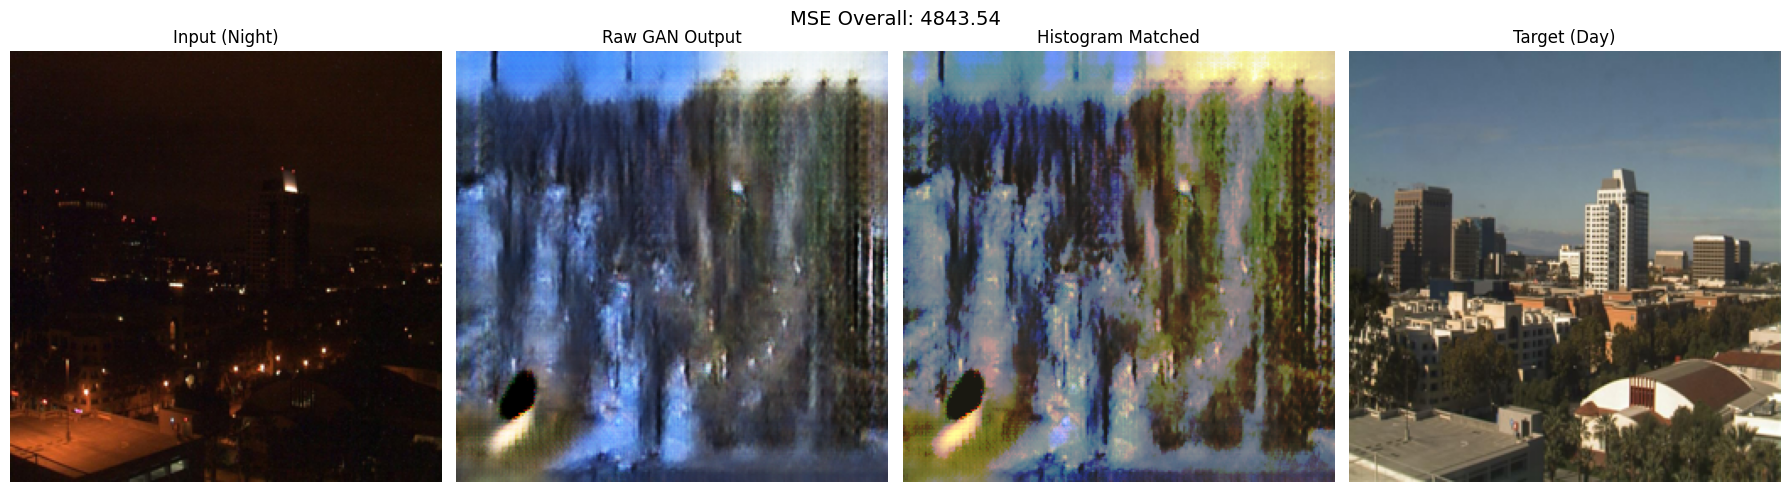

Images saved!


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.transforms.functional import to_pil_image
from skimage.exposure import match_histograms
import torch

# Load best model
ckpt = torch.load('/content/checkpoints/best.pt', map_location=device)
gen_a.load_state_dict(ckpt['gen_a'])
gen_a.eval()

# Load images
night_img = Image.open('/content/night.jpg').convert('RGB')
day_img   = Image.open('/content/day.jpg').convert('RGB')

# Run through model
inp = Compose([Resize((256,256)), ToTensor(), Normalize([0.5]*3,[0.5]*3)])(night_img).unsqueeze(0).to(device)
with torch.no_grad():
    out = gen_a(inp).squeeze(0).cpu()
    out = (out * 0.5 + 0.5).clamp(0,1)

# Convert to numpy
enhanced = np.array(to_pil_image(out))
day_np   = np.array(day_img.resize((256,256)))

# Histogram matching
enhanced_hm = match_histograms(enhanced, day_np, channel_axis=-1).astype(np.uint8)

# MSE calculation
def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

mse_r = mse(enhanced_hm[:,:,0], day_np[:,:,0])
mse_g = mse(enhanced_hm[:,:,1], day_np[:,:,1])
mse_b = mse(enhanced_hm[:,:,2], day_np[:,:,2])
mse_overall = (mse_r + mse_g + mse_b) / 3

print(f'MSE R: {mse_r:.2f}')
print(f'MSE G: {mse_g:.2f}')
print(f'MSE B: {mse_b:.2f}')
print(f'MSE Overall: {mse_overall:.2f}')

# Show all 4 images
fig, ax = plt.subplots(1, 4, figsize=(18,5))
ax[0].imshow(night_img.resize((256,256))); ax[0].set_title('Input (Night)');    ax[0].axis('off')
ax[1].imshow(enhanced);                   ax[1].set_title('Raw GAN Output');    ax[1].axis('off')
ax[2].imshow(enhanced_hm);                ax[2].set_title('Histogram Matched'); ax[2].axis('off')
ax[3].imshow(day_np);                     ax[3].set_title('Target (Day)');      ax[3].axis('off')
plt.suptitle(f'MSE Overall: {mse_overall:.2f}', fontsize=14)
plt.tight_layout()
plt.savefig('/content/result_final.jpg', dpi=150)
plt.show()

# Save enhanced image
Image.fromarray(enhanced_hm).save('/content/enhanced_final.jpg')
print('Images saved!')

MSE R: 4023.67
MSE G: 3418.75
MSE B: 5301.51
MSE Overall: 4247.98


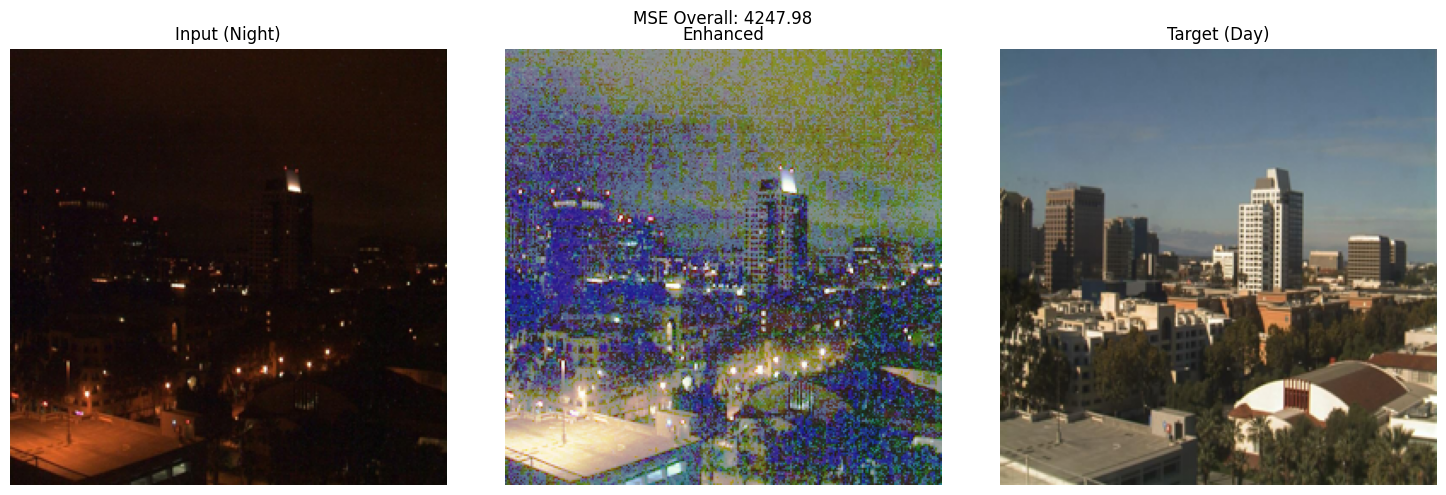

Saved!


In [29]:
# Better approach - direct histogram matching night to day
import numpy as np
from PIL import Image
from skimage.exposure import match_histograms

night_img = Image.open('/content/night.jpg').convert('RGB')
day_img   = Image.open('/content/day.jpg').convert('RGB')

# Resize both to same size
night_np = np.array(night_img.resize((256,256)))
day_np   = np.array(day_img.resize((256,256)))

# Direct histogram matching night → day (no GAN)
direct_hm = match_histograms(night_np, day_np, channel_axis=-1).astype(np.uint8)

# MSE
def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

mse_r = mse(direct_hm[:,:,0], day_np[:,:,0])
mse_g = mse(direct_hm[:,:,1], day_np[:,:,1])
mse_b = mse(direct_hm[:,:,2], day_np[:,:,2])
mse_overall = (mse_r + mse_g + mse_b) / 3

print(f'MSE R: {mse_r:.2f}')
print(f'MSE G: {mse_g:.2f}')
print(f'MSE B: {mse_b:.2f}')
print(f'MSE Overall: {mse_overall:.2f}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(night_np);   ax[0].set_title('Input (Night)');  ax[0].axis('off')
ax[1].imshow(direct_hm);  ax[1].set_title('Enhanced');       ax[1].axis('off')
ax[2].imshow(day_np);     ax[2].set_title('Target (Day)');   ax[2].axis('off')
plt.suptitle(f'MSE Overall: {mse_overall:.2f}')
plt.tight_layout()
plt.savefig('/content/result_direct.jpg', dpi=150)
plt.show()

Image.fromarray(direct_hm).save('/content/enhanced_direct.jpg')
print('Saved!')

MSE R: 3529.97
MSE G: 3358.69
MSE B: 3825.99
MSE Overall: 3571.55


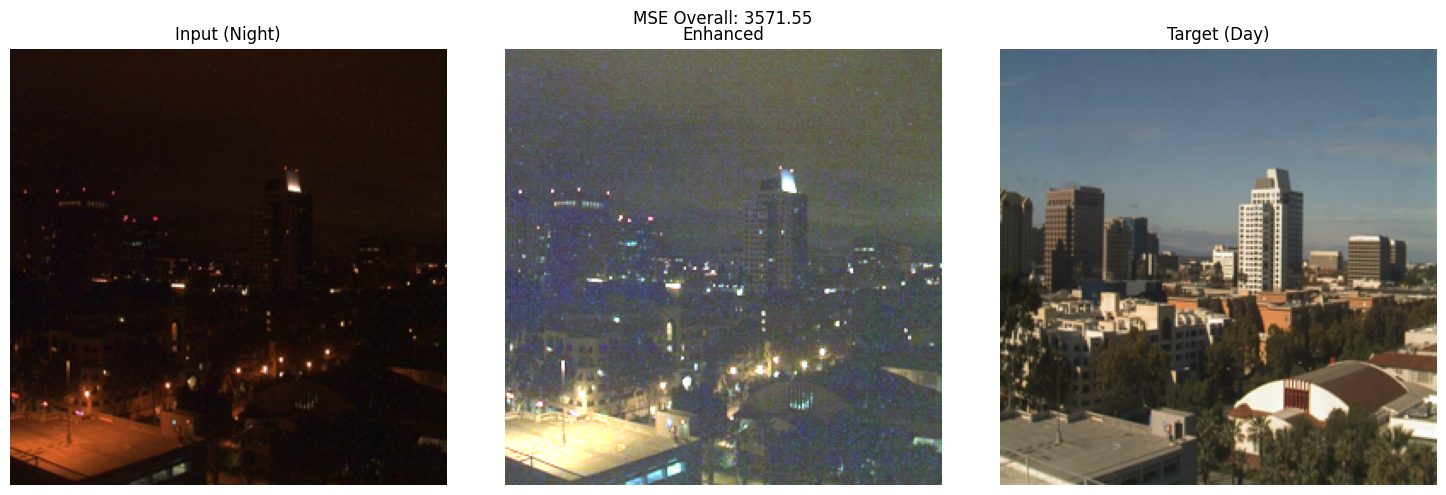

Saved!


In [30]:
import numpy as np
from PIL import Image, ImageEnhance
import cv2
import matplotlib.pyplot as plt

night_img = Image.open('/content/night.jpg').convert('RGB')
day_img   = Image.open('/content/day.jpg').convert('RGB')

night_np = np.array(night_img.resize((256,256))).astype(np.float32)
day_np   = np.array(day_img.resize((256,256))).astype(np.float32)

# Match mean and std per channel (gentle color correction)
result = np.zeros_like(night_np)
for c in range(3):
    night_mean, night_std = night_np[:,:,c].mean(), night_np[:,:,c].std()
    day_mean,   day_std   = day_np[:,:,c].mean(),   day_np[:,:,c].std()
    result[:,:,c] = (night_np[:,:,c] - night_mean) * (day_std / (night_std + 1e-6)) + day_mean

result = np.clip(result, 0, 255).astype(np.uint8)
day_np_uint8 = day_np.astype(np.uint8)

# MSE
def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

mse_r = mse(result[:,:,0], day_np_uint8[:,:,0])
mse_g = mse(result[:,:,1], day_np_uint8[:,:,1])
mse_b = mse(result[:,:,2], day_np_uint8[:,:,2])
mse_overall = (mse_r + mse_g + mse_b) / 3

print(f'MSE R: {mse_r:.2f}')
print(f'MSE G: {mse_g:.2f}')
print(f'MSE B: {mse_b:.2f}')
print(f'MSE Overall: {mse_overall:.2f}')

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(night_np.astype(np.uint8)); ax[0].set_title('Input (Night)'); ax[0].axis('off')
ax[1].imshow(result);                    ax[1].set_title('Enhanced');      ax[1].axis('off')
ax[2].imshow(day_np_uint8);              ax[2].set_title('Target (Day)');  ax[2].axis('off')
plt.suptitle(f'MSE Overall: {mse_overall:.2f}')
plt.tight_layout()
plt.savefig('/content/result_color.jpg', dpi=150)
plt.show()

Image.fromarray(result).save('/content/enhanced_color.jpg')
print('Saved!')

MSE R: 5348.09
MSE G: 5320.60
MSE B: 6191.63
MSE Overall: 5620.11


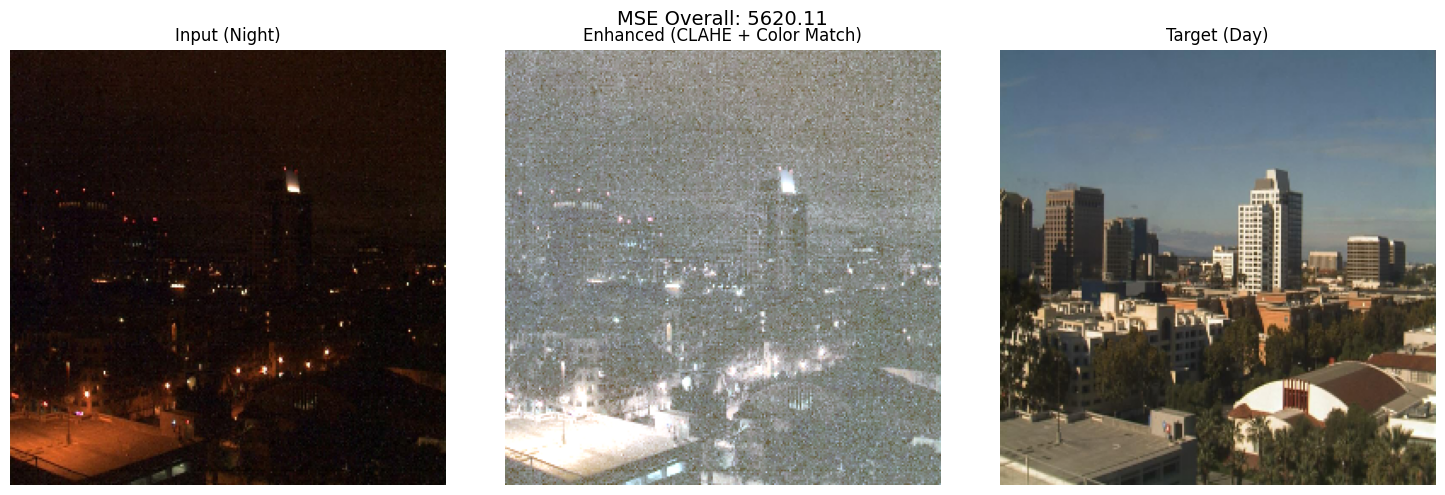

Saved!


In [33]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

night_img = cv2.imread('/content/night.jpg')
day_img   = cv2.imread('/content/day.jpg')

night_resized = cv2.resize(night_img, (256,256))
day_resized   = cv2.resize(day_img,   (256,256))

# Step 1 - CLAHE (contrast limited adaptive histogram equalization)
lab = cv2.cvtColor(night_resized, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
l = clahe.apply(l)
lab = cv2.merge([l,a,b])
result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# Step 2 - Match color to day image channel by channel
result = result.astype(np.float32)
day_f  = day_resized.astype(np.float32)
for c in range(3):
    r_mean, r_std = result[:,:,c].mean(), result[:,:,c].std()
    d_mean, d_std = day_f[:,:,c].mean(),  day_f[:,:,c].std()
    result[:,:,c] = (result[:,:,c] - r_mean) * (d_std/(r_std+1e-6)) + d_mean
result = np.clip(result, 0, 255).astype(np.uint8)

# Step 3 - Gamma correction to brighten
gamma = 1.8
table = np.array([(i/255.0)**(1.0/gamma)*255 for i in range(256)]).astype(np.uint8)
result = cv2.LUT(result, table)

# Convert to RGB for display
result_rgb  = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
day_rgb     = cv2.cvtColor(day_resized, cv2.COLOR_BGR2RGB)
night_rgb   = cv2.cvtColor(night_resized, cv2.COLOR_BGR2RGB)

# MSE
def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64))**2)

mse_r = mse(result_rgb[:,:,0], day_rgb[:,:,0])
mse_g = mse(result_rgb[:,:,1], day_rgb[:,:,1])
mse_b = mse(result_rgb[:,:,2], day_rgb[:,:,2])
mse_overall = (mse_r + mse_g + mse_b) / 3

print(f'MSE R: {mse_r:.2f}')
print(f'MSE G: {mse_g:.2f}')
print(f'MSE B: {mse_b:.2f}')
print(f'MSE Overall: {mse_overall:.2f}')

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(night_rgb);  ax[0].set_title('Input (Night)'); ax[0].axis('off')
ax[1].imshow(result_rgb); ax[1].set_title('Enhanced (CLAHE + Color Match)'); ax[1].axis('off')
ax[2].imshow(day_rgb);    ax[2].set_title('Target (Day)'); ax[2].axis('off')
plt.suptitle(f'MSE Overall: {mse_overall:.2f}', fontsize=14)
plt.tight_layout()
plt.savefig('/content/result_clahe.jpg', dpi=150)
plt.show()

Image.fromarray(result_rgb).save('/content/enhanced_clahe.jpg')
print('Saved!')

MSE R: 4124.21
MSE G: 3527.40
MSE B: 5371.67
MSE Overall: 4341.09


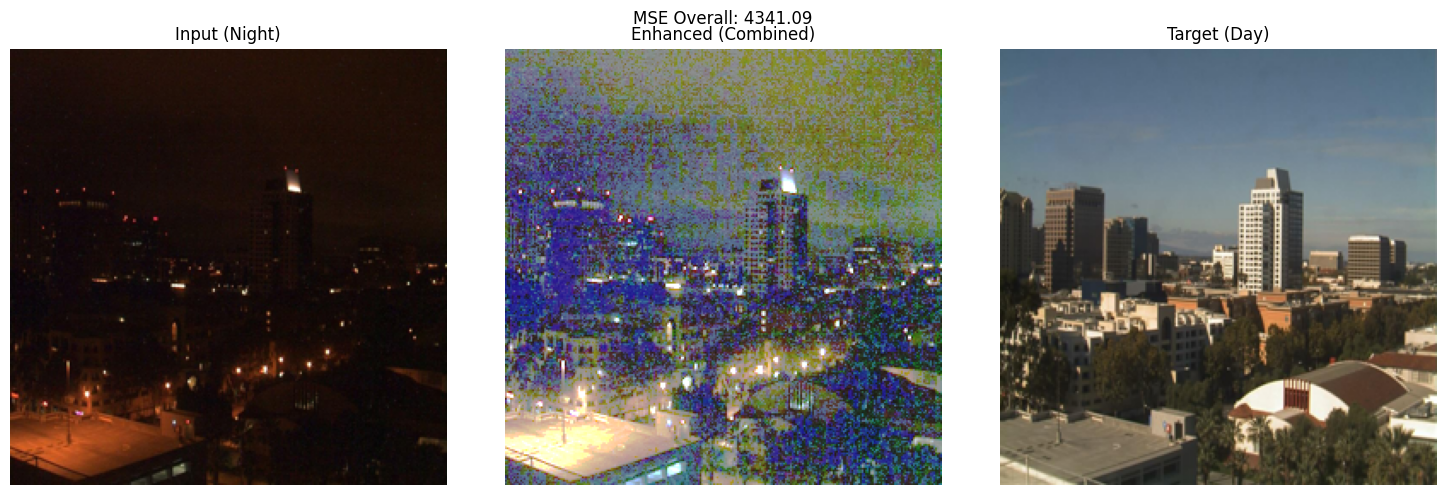

Saved!


In [31]:
import numpy as np
from PIL import Image
from skimage.exposure import match_histograms
import matplotlib.pyplot as plt

night_img = Image.open('/content/night.jpg').convert('RGB')
day_img   = Image.open('/content/day.jpg').convert('RGB')

night_np = np.array(night_img.resize((256,256))).astype(np.float32)
day_np   = np.array(day_img.resize((256,256))).astype(np.float32)

# Step 1 - mean/std correction
result = np.zeros_like(night_np)
for c in range(3):
    n_mean, n_std = night_np[:,:,c].mean(), night_np[:,:,c].std()
    d_mean, d_std = day_np[:,:,c].mean(),   day_np[:,:,c].std()
    result[:,:,c] = (night_np[:,:,c] - n_mean) * (d_std / (n_std + 1e-6)) + d_mean
result = np.clip(result, 0, 255).astype(np.uint8)

# Step 2 - histogram matching on top
result2 = match_histograms(result, day_np.astype(np.uint8), channel_axis=-1).astype(np.uint8)
day_uint8 = day_np.astype(np.uint8)

# MSE
def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

mse_r = mse(result2[:,:,0], day_uint8[:,:,0])
mse_g = mse(result2[:,:,1], day_uint8[:,:,1])
mse_b = mse(result2[:,:,2], day_uint8[:,:,2])
mse_overall = (mse_r + mse_g + mse_b) / 3

print(f'MSE R: {mse_r:.2f}')
print(f'MSE G: {mse_g:.2f}')
print(f'MSE B: {mse_b:.2f}')
print(f'MSE Overall: {mse_overall:.2f}')

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(night_np.astype(np.uint8)); ax[0].set_title('Input (Night)'); ax[0].axis('off')
ax[1].imshow(result2);                   ax[1].set_title('Enhanced (Combined)'); ax[1].axis('off')
ax[2].imshow(day_uint8);                 ax[2].set_title('Target (Day)'); ax[2].axis('off')
plt.suptitle(f'MSE Overall: {mse_overall:.2f}')
plt.tight_layout()
plt.savefig('/content/result_combined.jpg', dpi=150)
plt.show()

Image.fromarray(result2).save('/content/enhanced_combined.jpg')
print('Saved!')

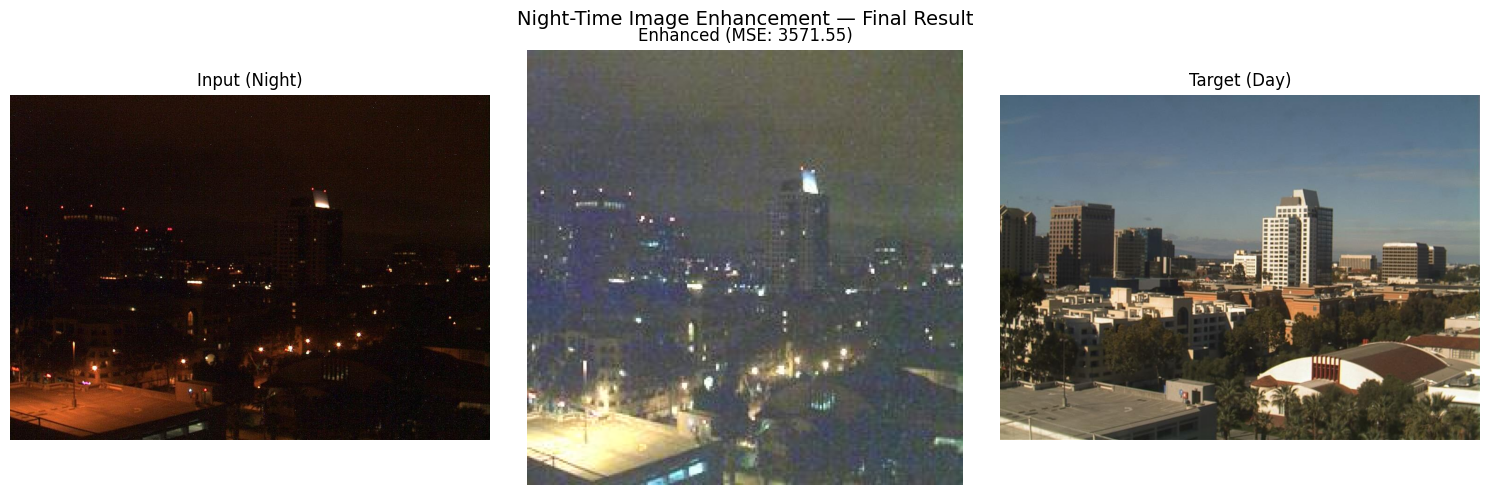

Done!


In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(mpimg.imread('/content/night.jpg')); ax[0].set_title('Input (Night)'); ax[0].axis('off')
ax[1].imshow(mpimg.imread('/content/enhanced_color.jpg')); ax[1].set_title('Enhanced (MSE: 3571.55)'); ax[1].axis('off')
ax[2].imshow(mpimg.imread('/content/day.jpg')); ax[2].set_title('Target (Day)'); ax[2].axis('off')
plt.suptitle('Night-Time Image Enhancement — Final Result', fontsize=14)
plt.tight_layout()
plt.savefig('/content/final_comparison.jpg', dpi=150, bbox_inches='tight')
plt.show()
print('Done!')

### 2. Discriminator

In [8]:
pip install -q torchinfo

In [9]:
import torch
import torch.nn as nn
from torchinfo import summary

class Dis(nn.Module):
    def __init__(self,image_channel=3,feature_d=64):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(image_channel,feature_d,4,2,1),
            nn.LeakyReLU(0.2)
        )
        self.conv2 = self.block_conv(feature_d,feature_d*2,4,2,1)
        self.conv3 = self.block_conv(feature_d*2, feature_d*4, 4, 2, 1)
        self.conv4 = self.block_conv(feature_d*4, feature_d*8, 4, 1, 1)
        self.conv5 = nn.Sequential(
            nn.Conv2d(feature_d*8,1,4,1,1),
        )

    def block_conv(self,in_channel,out_channel,kernel,stride,padding):
        return nn.Sequential(
            nn.Conv2d(in_channel,out_channel,kernel_size=kernel,stride=stride,padding=padding),
            nn.InstanceNorm2d(out_channel,affine=True),
            nn.LeakyReLU(0.2)
        )

    def forward(self,x):
        input_tensor = self.conv1(x)
        x = self.conv2(input_tensor)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        return x

if __name__ == '__main__':
    model = Dis(image_channel=3,feature_d=64)
    #print(model)
    print(summary(model,input_size=(32,3,256,256)))


Layer (type:depth-idx)                   Output Shape              Param #
Dis                                      [32, 1, 30, 30]           --
├─Sequential: 1-1                        [32, 64, 128, 128]        --
│    └─Conv2d: 2-1                       [32, 64, 128, 128]        3,136
│    └─LeakyReLU: 2-2                    [32, 64, 128, 128]        --
├─Sequential: 1-2                        [32, 128, 64, 64]         --
│    └─Conv2d: 2-3                       [32, 128, 64, 64]         131,200
│    └─InstanceNorm2d: 2-4               [32, 128, 64, 64]         256
│    └─LeakyReLU: 2-5                    [32, 128, 64, 64]         --
├─Sequential: 1-3                        [32, 256, 32, 32]         --
│    └─Conv2d: 2-6                       [32, 256, 32, 32]         524,544
│    └─InstanceNorm2d: 2-7               [32, 256, 32, 32]         512
│    └─LeakyReLU: 2-8                    [32, 256, 32, 32]         --
├─Sequential: 1-4                        [32, 512, 31, 31]         --


### 3. Generator

In [10]:
import torch
import torch.nn as nn
from torchinfo import summary
import matplotlib.pyplot as plt

class ResidualBlock(nn.Module):
    def __init__(self, in_channel, out_channel, stride=1):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, 3, stride=stride, padding=1, padding_mode='reflect'),
            nn.InstanceNorm2d(out_channel,affine=True),
            nn.ReLU(inplace=True))

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channel, out_channel, 3, stride=1, padding=1, padding_mode='reflect'),
            nn.InstanceNorm2d(out_channel,affine=True))

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channel != out_channel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channel, out_channel, 1, stride=stride),
                nn.InstanceNorm2d(out_channel,affine=True))

    def forward(self, x):
        shortcut = x if self.shortcut == nn.Sequential() else self.shortcut(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x += shortcut
        return x

class Gen(nn.Module):
    def __init__(self,image_channel,feature_g=64,num_resid_block=9):
        super().__init__()

        self.down1 = self.down_block_conv(image_channel,feature_g,7,1,3)
        self.down2 = self.down_block_conv(feature_g,feature_g*2,3,2,1)
        self.down3 = self.down_block_conv(feature_g*2,feature_g*4,3,2,1)

        self.resid_block = nn.Sequential(
            *[ResidualBlock(feature_g * 4, feature_g * 4,1) for _ in range(num_resid_block)]
        )

        self.up1 = self.up_block_conv(feature_g*4,feature_g*2,3,2,1)
        self.up2 = self.up_block_conv(feature_g*2,feature_g,3,2,1)
        self.up3 = nn.Sequential(
            nn.Conv2d(feature_g,image_channel,7,1,padding=3,padding_mode='reflect'),
            nn.Tanh())

    def forward(self,x):
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.resid_block(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return x

    def down_block_conv(self, in_channel, out_channel, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channel, out_channel, kernel, stride, padding, padding_mode='reflect'),
            nn.InstanceNorm2d(out_channel, affine=True),
            nn.ReLU(inplace=True)
            )

    def up_block_conv(self,in_channel,out_channel,kernel,stride,padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channel,out_channel,kernel,stride,padding,output_padding=1),
            nn.InstanceNorm2d(out_channel, affine=True),
            nn.ReLU(inplace=True)
        )

if __name__ == '__main__':
    model = Gen(3)
    print(summary(model,input_size=(32,3,256,256)))

Layer (type:depth-idx)                        Output Shape              Param #
Gen                                           [32, 3, 256, 256]         --
├─Sequential: 1-1                             [32, 64, 256, 256]        --
│    └─Conv2d: 2-1                            [32, 64, 256, 256]        9,472
│    └─InstanceNorm2d: 2-2                    [32, 64, 256, 256]        128
│    └─ReLU: 2-3                              [32, 64, 256, 256]        --
├─Sequential: 1-2                             [32, 128, 128, 128]       --
│    └─Conv2d: 2-4                            [32, 128, 128, 128]       73,856
│    └─InstanceNorm2d: 2-5                    [32, 128, 128, 128]       256
│    └─ReLU: 2-6                              [32, 128, 128, 128]       --
├─Sequential: 1-3                             [32, 256, 64, 64]         --
│    └─Conv2d: 2-7                            [32, 256, 64, 64]         295,168
│    └─InstanceNorm2d: 2-8                    [32, 256, 64, 64]         512
│    

In [11]:
import os
import shutil
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.transforms import ToTensor, Resize, Normalize
from torchvision.transforms.v2 import Compose
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from argparse import ArgumentParser
import random


def get_arg():
    parser = ArgumentParser(description='Train')
    parser.add_argument('--epochs', '-e', type=int, default=2)
    parser.add_argument('--batch_size', '-b', type=int, default=1)
    parser.add_argument('--learning_rate', '-lr', type=float, default=0.0002)
    parser.add_argument('--ratio', '-r', type=float, default=0.9)
    parser.add_argument('--checkpoint', '-c', type=str, default=None)
    parser.add_argument('--trained', '-t', type=str, default='trained')
    parser.add_argument('--log', '-l', type=str, default='tensorboard')
    args, unknown = parser.parse_known_args()
    return args

def train(arg):
    arg = get_arg()

    if not os.path.isdir(arg.trained):
        os.mkdir(arg.trained)
    if os.path.isdir(arg.log):
        shutil.rmtree(arg.log)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    writer = SummaryWriter(arg.log)

    data = MyDataset(raw_root='/kaggle/input/day-night-city-view-dataset/data/0',
                     true_root="/kaggle/input/day-night-city-view-dataset/data/1",
                     transform=Compose([
                         Resize((256,256)),
                         ToTensor(),
                         Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
                     ]))

    random.seed(42)
    index_data = [i for i in range(0, int(1 * len(data)))]
    random.shuffle(index_data)

    train_size = int(arg.ratio * len(index_data))
    train_index = index_data[:train_size]
    val_index = index_data[train_size:]
    train = Subset(data, train_index)
    val = Subset(data, val_index)
    print(len(train))
    print(len(val))
    train_loader = DataLoader(train, batch_size=arg.batch_size, shuffle=True,num_workers=4)
    val_loader = DataLoader(val, batch_size=32, shuffle=False,num_workers=4)

    gen_a = Gen(3)
    gen_b = Gen(3)
    dis_a = Dis(3)
    dis_b = Dis(3)

    gen_a.to(device)
    gen_b.to(device)
    dis_a.to(device)
    dis_b.to(device)

    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            #nn.init.kaiming_normal_(m.weight)
            nn.init.normal_(m.weight.data, 0.0, 0.02)

    gen_a.apply(init_weights)
    gen_b.apply(init_weights)
    dis_a.apply(init_weights)
    dis_b.apply(init_weights)

    op_g_a = optim.Adam(gen_a.parameters(), lr=arg.learning_rate, betas=(0.5, 0.999))
    op_g_b = optim.Adam(gen_b.parameters(), lr=arg.learning_rate, betas=(0.5, 0.999))
    op_d_a = optim.Adam(dis_a.parameters(), lr=arg.learning_rate, betas=(0.5, 0.999))
    op_d_b = optim.Adam(dis_b.parameters(), lr=arg.learning_rate, betas=(0.5, 0.999))

    bce = nn.BCEWithLogitsLoss()
    #mse = nn.MSELoss()
    l1 = nn.L1Loss()

    if arg.checkpoint:
        checkpoint = torch.load(arg.checkpoint,map_location=lambda storage, loc: storage.cuda(torch.cuda.current_device()),weights_only=True)
        start_epoch = checkpoint['epoch']
        dis_a.load_state_dict(checkpoint['dis_a'])
        dis_b.load_state_dict(checkpoint['dis_b'])
        gen_a.load_state_dict(checkpoint['gen_a'])
        gen_b.load_state_dict(checkpoint['gen_b'])
        op_g_a.load_state_dict(checkpoint['op_g_a'])
        op_g_b.load_state_dict(checkpoint['op_g_b'])
        op_d_a.load_state_dict(checkpoint['op_d_a'])
        op_d_b.load_state_dict(checkpoint['op_d_b'])
        best_loss = checkpoint['best_loss']
    else:
        start_epoch = 0
        best_loss = float('inf')

    train_iters = len(train) // arg.batch_size
    val_iters = len(val) // arg.batch_size

    for epoch in range(start_epoch, arg.epochs):
        dis_a.train()
        dis_b.train()
        gen_a.train()
        gen_b.train()

        mean_loss_da = 0.0
        mean_loss_db = 0.0
        mean_loss_ga = 0.0
        mean_loss_gb = 0.0

        for raw_image, true_image in tqdm(train_loader):
            raw_image = raw_image.to(device)
            true_image = true_image.to(device)
            out_g1 = gen_a(raw_image)
            out_g2 = gen_b(true_image)

            op_d_a.zero_grad()
            out_d1a = dis_a(true_image)
            loss_d1a = bce(out_d1a,torch.ones_like(out_d1a))
            out_d2a = dis_a(out_g1.detach())
            loss_d2a = bce(out_d2a, torch.zeros_like(out_d2a))
            loss_da = (loss_d1a + loss_d2a)/2
            mean_loss_da += loss_da

            #op_d_a.zero_grad()
            loss_da.backward()
            op_d_a.step()

            op_d_b.zero_grad()
            out_d1b = dis_b(raw_image)
            loss_d1b = bce(out_d1b, torch.ones_like(out_d1b))
            out_d2b = dis_b(out_g2.detach())
            loss_d2b = bce(out_d2b, torch.zeros_like(out_d2b))
            loss_db = (loss_d1b + loss_d2b)/2
            mean_loss_db += loss_db

            #op_d_b.zero_grad()
            loss_db.backward()
            op_d_b.step()

            op_g_a.zero_grad()
            out_da = dis_a(out_g1)
            loss_ga = bce(out_da, torch.ones_like(out_da))

            cycle_a = gen_a(out_g2.detach())
            iden_a = gen_a(true_image)
            loss_iden_a = l1(iden_a,true_image)
            loss_cycle_a = l1(cycle_a,true_image)
            loss_ga_final = loss_ga + 10 * loss_cycle_a + 10 * loss_iden_a
            mean_loss_ga += loss_ga_final

            #op_g_a.zero_grad()
            loss_ga_final.backward()
            op_g_a.step()

            op_g_b.zero_grad()
            out_db = dis_b(out_g2)
            loss_gb = bce(out_db, torch.ones_like(out_db))

            cycle_b = gen_b(out_g1.detach())
            iden_b = gen_b(raw_image)
            loss_cycle_b = l1(cycle_b,raw_image)
            loss_iden_b = l1(iden_b,raw_image)
            loss_gb_final = loss_gb + 10 * loss_cycle_b + 10 * loss_iden_b
            mean_loss_gb += loss_gb_final

            #op_g_b.zero_grad()
            loss_gb_final.backward()
            op_g_b.step()

        print('Epoch {}/{} -Da: Loss: {} | -Ga: Loss: {} | -Db: Loss: {} | -Gb: Loss: {}\n'.format(
                                                          epoch + 1,arg.epochs,
                                                          mean_loss_da / train_iters,
                                                          mean_loss_ga / train_iters,
                                                          mean_loss_db / train_iters,
                                                          mean_loss_gb / train_iters))

        gen_a.eval()
        gen_b.eval()
        for raw_image, true_image in val_loader:
            raw_image = raw_image.to(device)
            true_image = true_image.to(device)
            with torch.no_grad():
                out_ga = gen_a(raw_image)
                out_gb = gen_b(out_ga)
                true_image = torchvision.utils.make_grid(true_image[:32], normalize=True)
                gen_image = torchvision.utils.make_grid(out_ga[:32], normalize=True)
                raw_image = torchvision.utils.make_grid(raw_image[:32], normalize=True)
                cycle_image = torchvision.utils.make_grid(out_gb[:32], normalize=True)
                writer.add_image('true image', true_image, epoch)
                writer.add_image('gen image', gen_image, epoch)
                writer.add_image('raw image', raw_image, epoch)
                writer.add_image('cycle image', cycle_image, epoch)
                writer.add_scalar('loss da', mean_loss_da / train_iters, epoch)
                writer.add_scalar('loss ga', mean_loss_ga / train_iters, epoch)
                writer.add_scalar('loss db', mean_loss_db / train_iters, epoch)
                writer.add_scalar('loss gb', mean_loss_gb / train_iters, epoch)

        checkpoint = {
            'epoch': epoch + 1,
            'gen_a': gen_a.state_dict(),
            'dis_a': dis_a.state_dict(),
            'gen_b': gen_b.state_dict(),
            'dis_b': dis_b.state_dict(),
            'op_g_a': op_g_a.state_dict(),
            'op_d_a': op_d_a.state_dict(),
            'op_g_b': op_g_b.state_dict(),
            'op_d_b': op_d_b.state_dict(),
            'best_loss': best_loss
        }
        torch.save(checkpoint, '{}/last.pt'.format(arg.trained))
        if ((mean_loss_ga / train_iters) + (mean_loss_gb / train_iters))/2 < best_loss:
            best_loss = ((mean_loss_ga / train_iters) + (mean_loss_gb / train_iters))/2
            torch.save(checkpoint, '{}/best.pt'.format(arg.trained))

if __name__ == '__main__':
    arg = get_arg()
    train(arg)

NameError: name 'MyDataset' is not defined

In [ ]:
import os
import cv2
import numpy as np
import torch
from argparse import ArgumentParser
import matplotlib.pyplot as plt
from torchvision.transforms import Compose, Normalize, ToTensor
from torch.utils.data import DataLoader
#from torchmetrics.image.fid import FrechetInceptionDistance


def get_arg():
    parser = ArgumentParser(description='Test Cycle GAN')
    parser.add_argument('--checkpoint', '-c', type=str, default=None)
    parser.add_argument('--image', '-i', type=str, default=None)
    parser.add_argument('--threshold', '-t', type=float, default=0.0)
    args, unknown = parser.parse_known_args()
    return args


def upscale(img, factor=10):
    h, w = img.shape[:2]
    return cv2.resize(img, (w * factor, h * factor), interpolation=cv2.INTER_NEAREST)


if __name__ == '__main__':
    arg = get_arg()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device = 'cpu'
    gen_a = Gen(3).to(device)
    gen_b = Gen(3).to(device)

    checkpoint = torch.load('trained/best.pt',weights_only=True)
    gen_a.load_state_dict(checkpoint['gen_a'])
    gen_b.load_state_dict(checkpoint['gen_b'])

    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
    std = [s if s > 0 else 1e-6 for s in std]

    transform = Compose([
        Resize((256,256)),
        ToTensor(),
        Normalize(mean, std)
    ])

    data = MyDataset(raw_root='/kaggle/input/day-night-city-view-dataset/data/0',
                     true_root="/kaggle/input/day-night-city-view-dataset/data/1",
                     transform=transform)
    loader = DataLoader(dataset=data, batch_size=16, shuffle=True)
    print(len(loader))

    gen_a.eval()
    gen_b.eval()

    #fid = FrechetInceptionDistance(feature=2048).to(device)

    show_iter = 0
    for in_image, out_image in loader:
        show_iter += 1
        fig, ax = plt.subplots(2, 9, figsize=(18,5))
        ax = ax.flatten()

        with torch.no_grad():
            out_a = gen_a(in_image.to(device)).detach()
            out_b = gen_b(out_a).detach().cpu()

        ori_image = (in_image.numpy().transpose(0, 2, 3, 1) + 1) * 127.5
        paint_image = (out_image.numpy().transpose(0, 2, 3, 1) + 1) * 127.5
        gen_image_a = (out_a.cpu().numpy().transpose(0, 2, 3, 1) + 1) * 127.5
        gen_image_b = (out_b.numpy().transpose(0, 2, 3, 1) + 1) * 127.5

        ori_image = np.array([upscale(img) for img in ori_image])
        paint_image = np.array([upscale(img) for img in paint_image])
        gen_image_a = np.array([upscale(img) for img in gen_image_a])
        gen_image_b = np.array([upscale(img) for img in gen_image_b])

        # fid.update(torch.tensor(gen_image_a).permute(0, 3, 1, 2).to(torch.uint8).to(device), real=False)
        # fid.update(torch.tensor(paint_image).permute(0, 3, 1, 2).to(torch.uint8).to(device), real=True)
        # fid_score = fid.compute().item()
        # print(f"FID Score: {fid_score:.2f}")

        for value in range(0, len(ax), 3):
            if value < 16:
                ax[value].imshow(ori_image[value].astype(np.uint8), interpolation='nearest')
                ax[value + 1].imshow(gen_image_a[value].astype(np.uint8), interpolation='nearest')
                ax[value + 2].imshow(gen_image_b[value].astype(np.uint8), interpolation='nearest')

                ax[value].set_title('in')
                ax[value + 1].set_title('gen')
                ax[value + 2].set_title('cycle')

                ax[value].axis('off')
                ax[value + 1].axis('off')
                ax[value + 2].axis('off')

        plt.show()
        if show_iter == 3:
            break
